## Task 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/sample_data/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


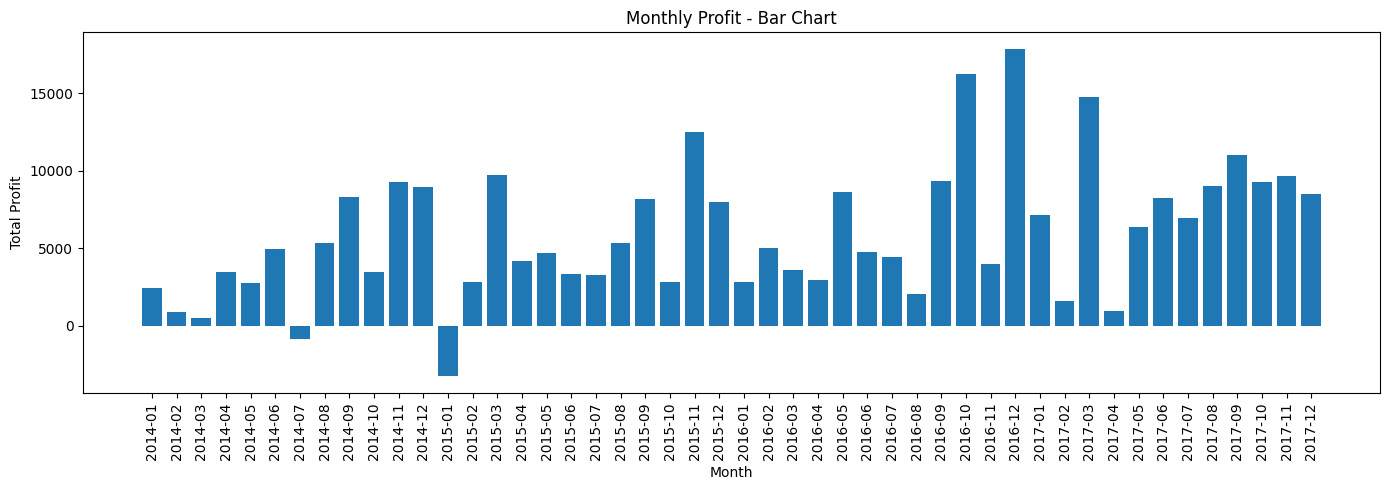

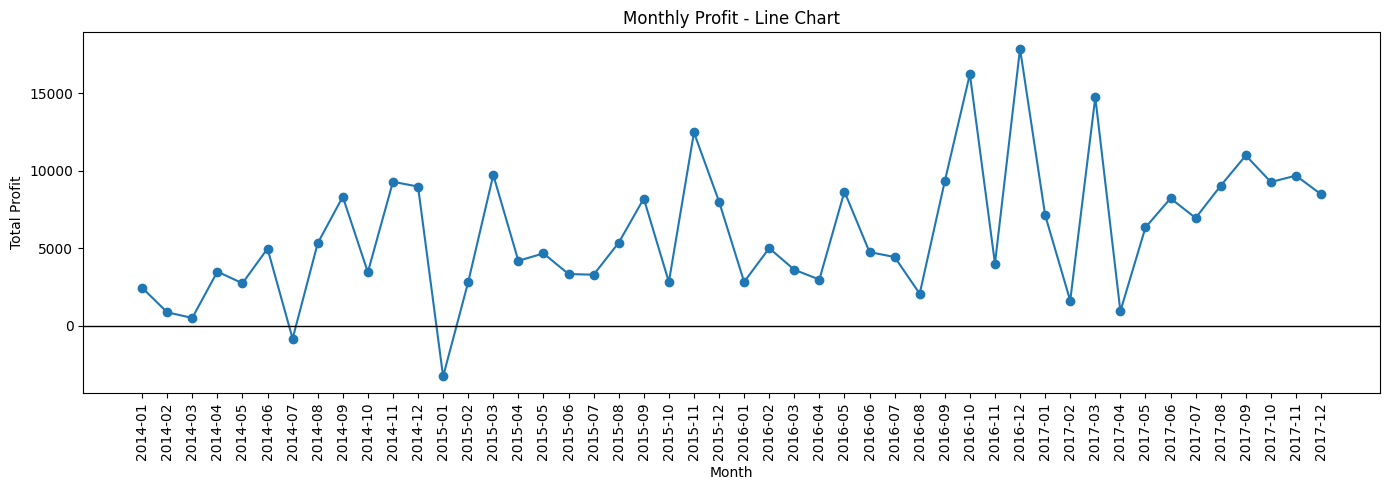

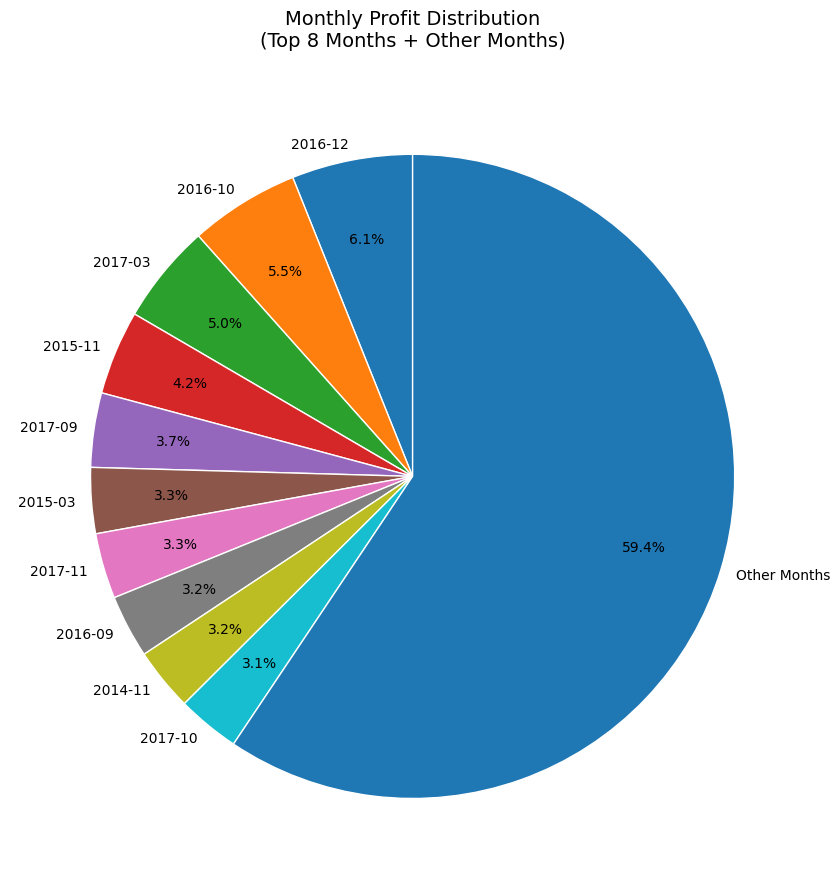

In [ ]:

df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(14, 5))
plt.bar(monthly_profit.index, monthly_profit.values)
plt.xticks(rotation=90)
plt.title('Monthly Profit - Bar Chart')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(monthly_profit.index, monthly_profit.values, marker='o')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=90)
plt.title('Monthly Profit - Line Chart')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

pie_data = monthly_profit.abs().sort_values(ascending=False)

top_months = pie_data.head(10)
other_profit = pie_data.iloc[10:].sum()

pie_data_clean = pd.concat([
    top_months,
    pd.Series({'Other Months': other_profit})
])

plt.figure(figsize=(9, 9))

plt.pie(
    pie_data_clean.values,
    labels=pie_data_clean.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.05,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.title(
    'Monthly Profit Distribution\n(Top 8 Months + Other Months)',
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

## Task 2

### 2.1 Compare total profit across the top 5 sub-categories

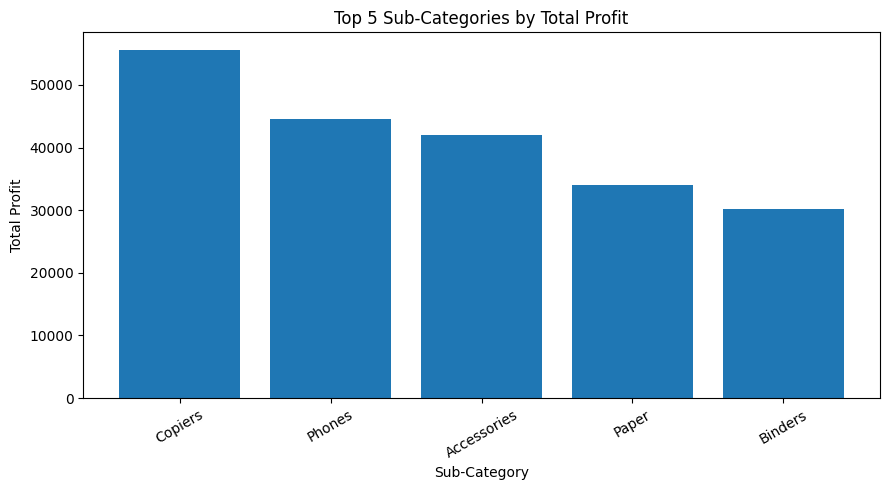

In [ ]:
top5_profit = df.groupby('Sub-Category')['Profit'].sum().nlargest(5)

plt.figure(figsize=(9, 5))
plt.bar(top5_profit.index, top5_profit.values)
plt.title('Top 5 Sub-Categories by Total Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2.2 Show profit trend over time

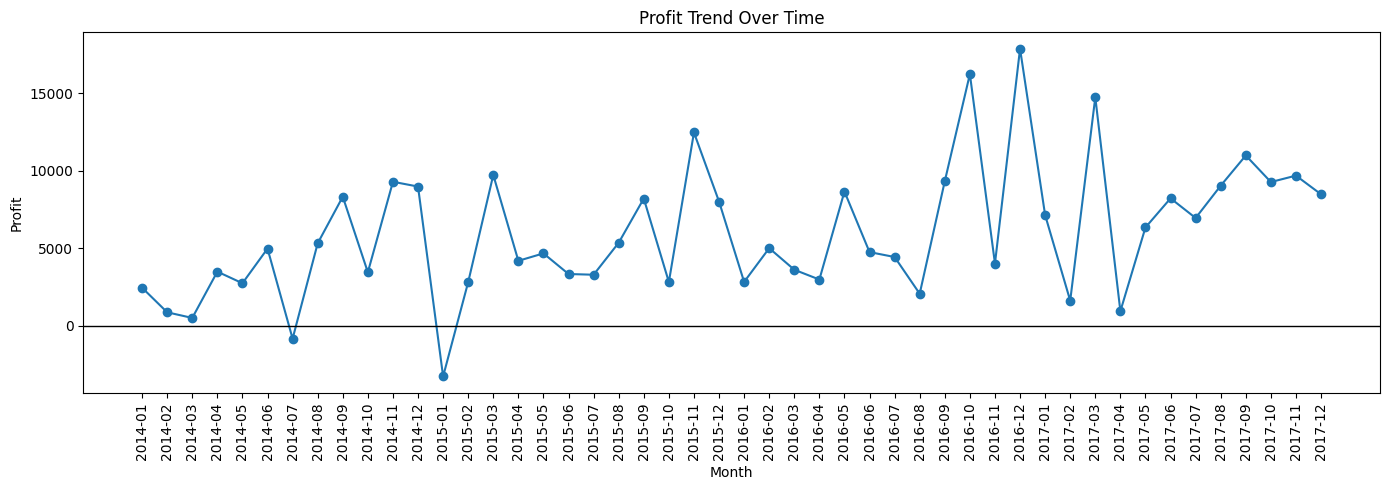

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_profit.index, monthly_profit.values, marker='o')
plt.axhline(0, color='black', linewidth=1)
plt.title('Profit Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.3 Show distribution of order-line profit values

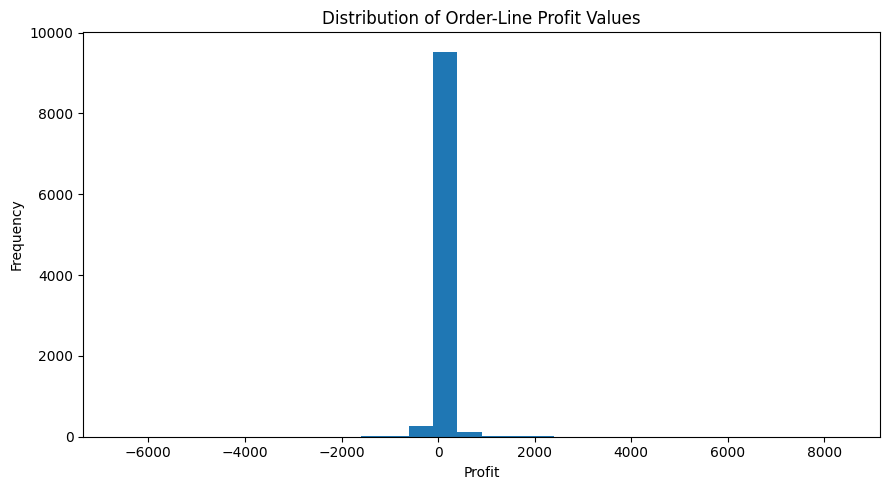

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df['Profit'].dropna(), bins=30)
plt.title('Distribution of Order-Line Profit Values')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 2.4 Show relationship between discount and profit

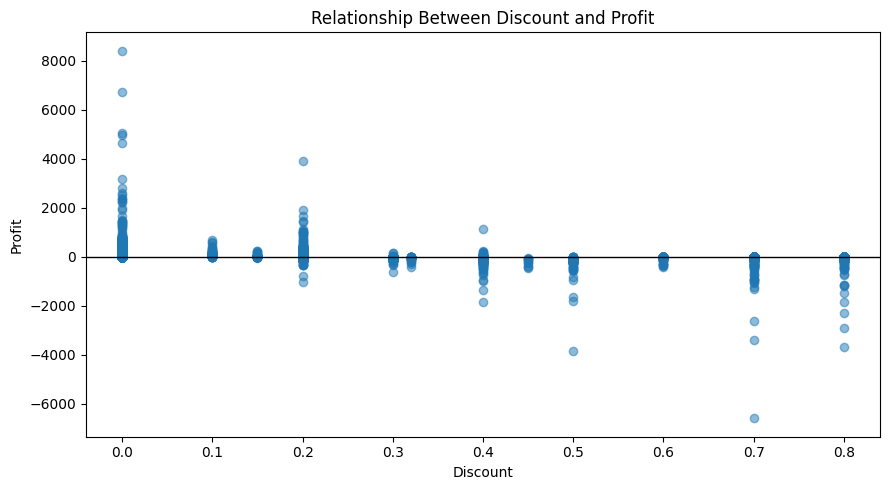

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

## Task 3

### 3(a) Region profit with categorical palette

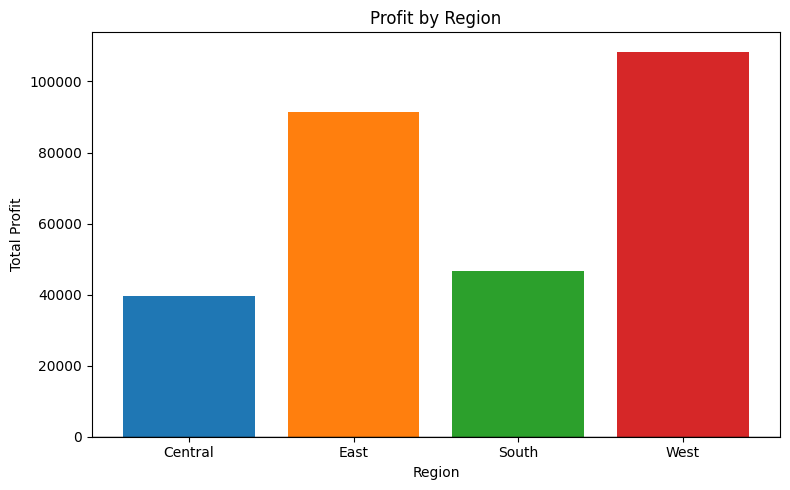

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8, 5))
plt.bar(
    region_profit.index,
    region_profit.values,
    color=plt.cm.tab10(range(len(region_profit)))
)
plt.axhline(0, color='black', linewidth=1)
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

### 3(b) Region-by-category profit heatmap using sequential palette


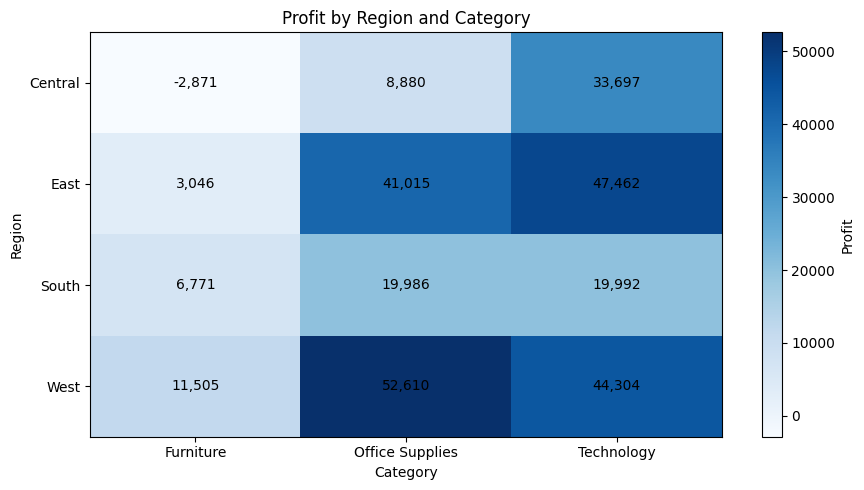

In [ ]:
region_category_profit = pd.pivot_table(
    df,
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(9, 5))
plt.imshow(region_category_profit, cmap='Blues', aspect='auto')
plt.colorbar(label='Profit')

plt.xticks(
    range(len(region_category_profit.columns)),
    region_category_profit.columns
)

plt.yticks(
    range(len(region_category_profit.index)),
    region_category_profit.index
)

plt.title('Profit by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')

for i in range(len(region_category_profit.index)):
    for j in range(len(region_category_profit.columns)):
        plt.text(
            j,
            i,
            f'{region_category_profit.iloc[i, j]:,.0f}',
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

### 3(c) Monthly profit using a diverging palette


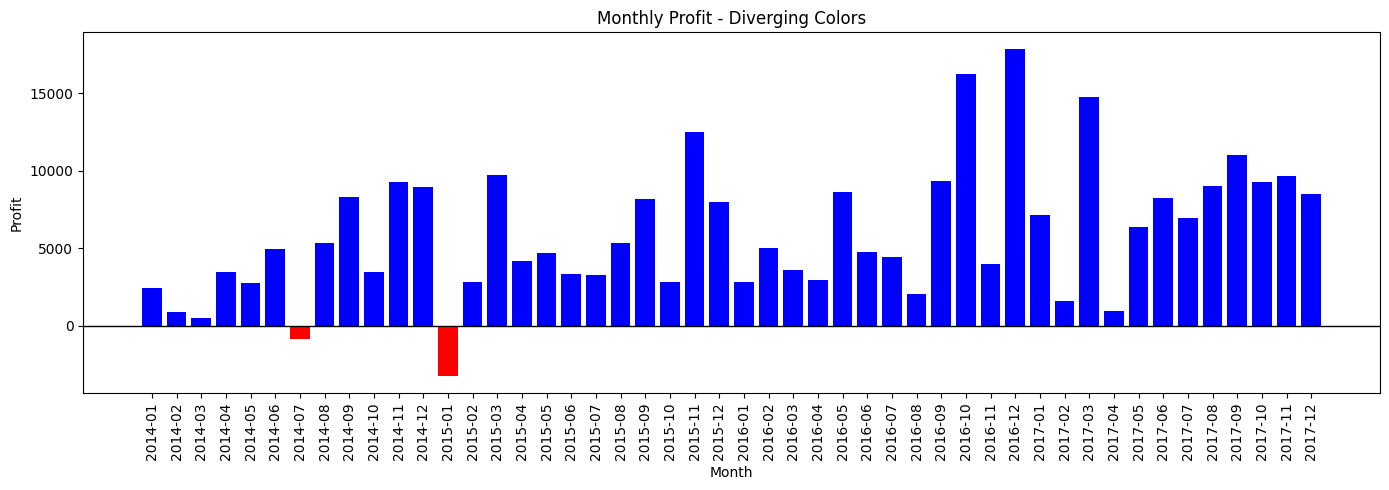

In [ ]:
colors = [
    'red' if value < 0 else 'blue'
    for value in monthly_profit.values
]

plt.figure(figsize=(14, 5))
plt.bar(
    monthly_profit.index,
    monthly_profit.values,
    color=colors
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Monthly Profit - Diverging Colors')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Task 4

### 4(a) WCAG contrast ratio function


In [ ]:
def relative_luminance(rgb):
    rgb = [x / 255 for x in rgb]

    values = []

    for x in rgb:
        if x <= 0.03928:
            values.append(x / 12.92)
        else:
            values.append(((x + 0.055) / 1.055) ** 2.4)

    return (
        0.2126 * values[0]
        + 0.7152 * values[1]
        + 0.0722 * values[2]
    )


def contrast_ratio(color1, color2):
    l1 = relative_luminance(color1)
    l2 = relative_luminance(color2)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)


colors_to_test = {
    'Red': (255, 0, 0),
    'Blue': (0, 0, 255),
    'Black': (0, 0, 0),
    'White': (255, 255, 255)
}

background = (255, 255, 255)

for name, rgb in colors_to_test.items():
    ratio = contrast_ratio(rgb, background)
    status = 'PASS' if ratio >= 4.5 else 'FAIL'

    print(f'{name}: {ratio:.2f}:1 -> {status}')

Red: 4.00:1 -> FAIL
Blue: 8.59:1 -> PASS
Black: 21.00:1 -> PASS
White: 1.00:1 -> FAIL


### 4(b) Profit by sub-category using red and green only

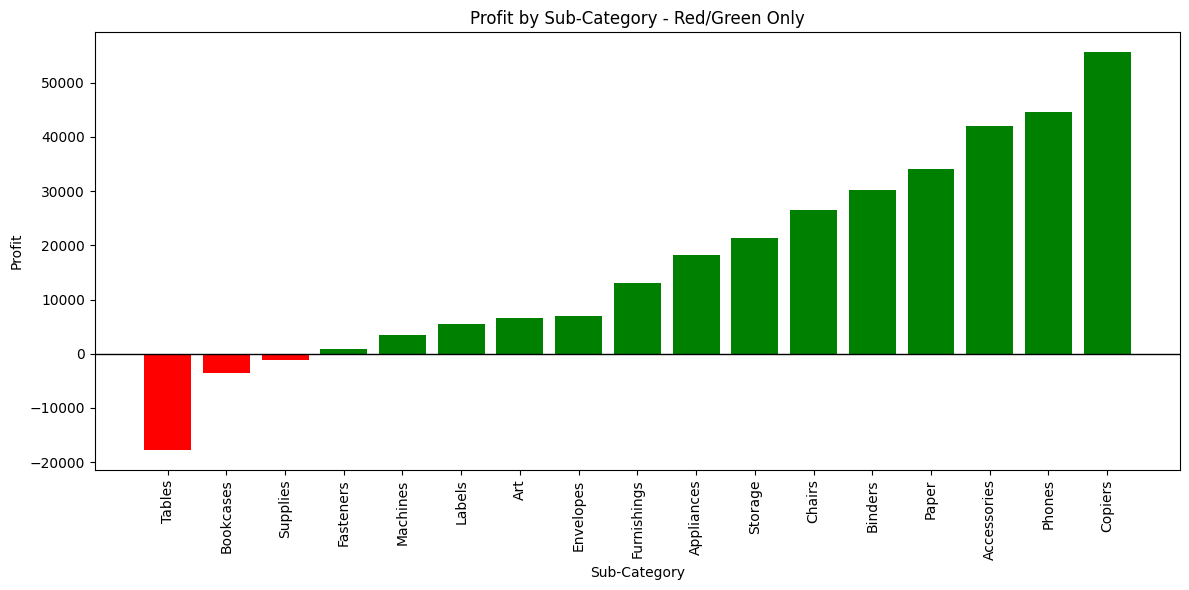

In [ ]:
subcategory_profit = df.groupby(
    'Sub-Category'
)['Profit'].sum().sort_values()

plt.figure(figsize=(12, 6))

plt.bar(
    subcategory_profit.index,
    subcategory_profit.values,
    color=[
        'green' if value >= 0 else 'red'
        for value in subcategory_profit.values
    ]
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Profit by Sub-Category - Red/Green Only')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4(c) Accessible corrected chart using color and hatching


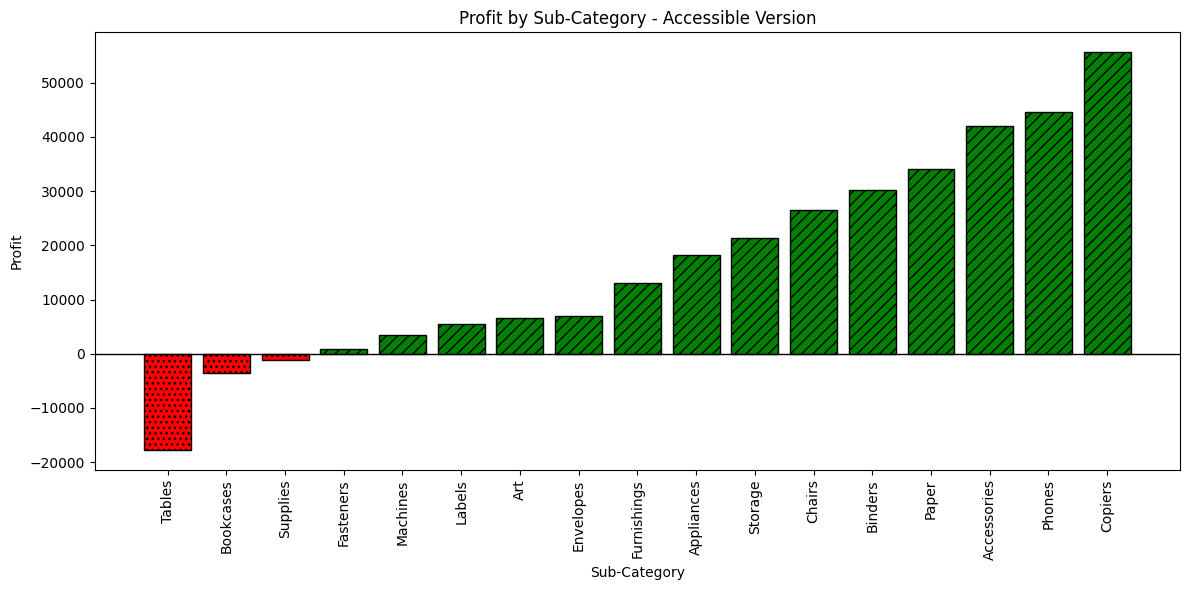

Alt text: The chart shows total profit by sub-category, with gains shown using diagonal hatching and losses using dotted hatching.


In [ ]:
plt.figure(figsize=(12, 6))

for i, (name, value) in enumerate(subcategory_profit.items()):

    if value >= 0:
        plt.bar(
            i,
            value,
            color='green',
            hatch='///',
            edgecolor='black'
        )
    else:
        plt.bar(
            i,
            value,
            color='red',
            hatch='...',
            edgecolor='black'
        )

plt.axhline(0, color='black', linewidth=1)
plt.xticks(
    range(len(subcategory_profit)),
    subcategory_profit.index,
    rotation=90
)

plt.title('Profit by Sub-Category - Accessible Version')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

print(
    'Alt text: The chart shows total profit by sub-category, '
    'with gains shown using diagonal hatching and losses using dotted hatching.'
)

## Task 5

### 5(a) Truncated y-axis

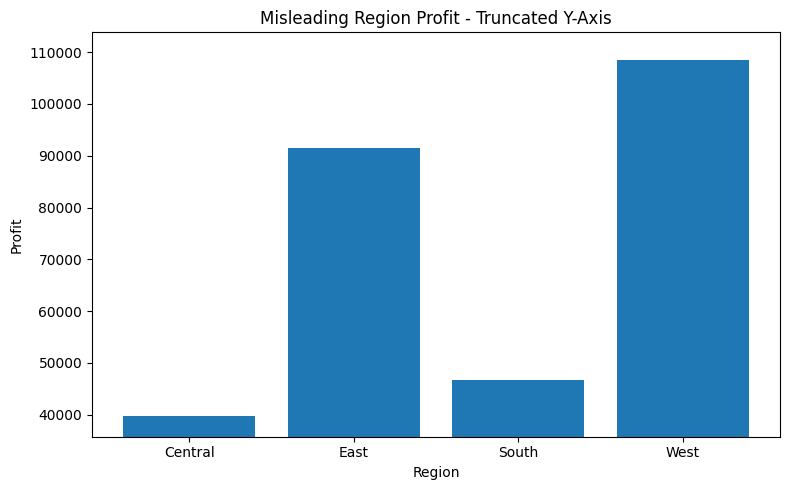

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(region_profit.index, region_profit.values)

plt.ylim(
    region_profit.min() * 0.90,
    region_profit.max() * 1.05
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Misleading Region Profit - Truncated Y-Axis')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### 5(b) Dual-axis chart

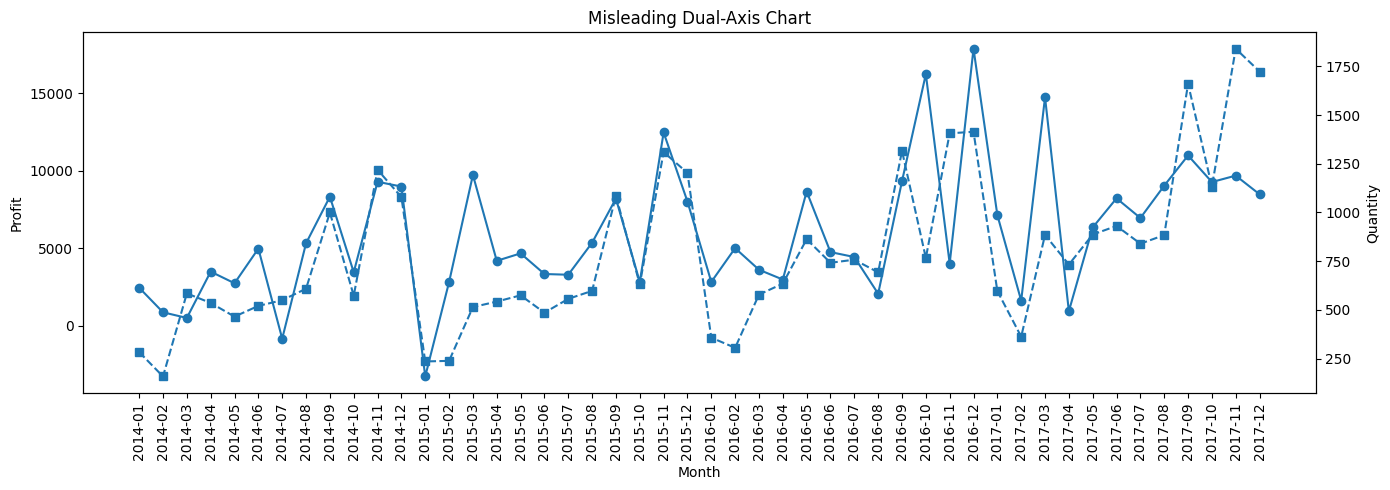

In [ ]:
monthly_quantity = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Quantity'].sum()

monthly_quantity.index = monthly_quantity.index.astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker='o'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Profit')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    marker='s',
    linestyle='--'
)

ax2.set_ylabel('Quantity')

plt.title('Misleading Dual-Axis Chart')
plt.tight_layout()
plt.show()

### 5(c) Cherry-picked date window

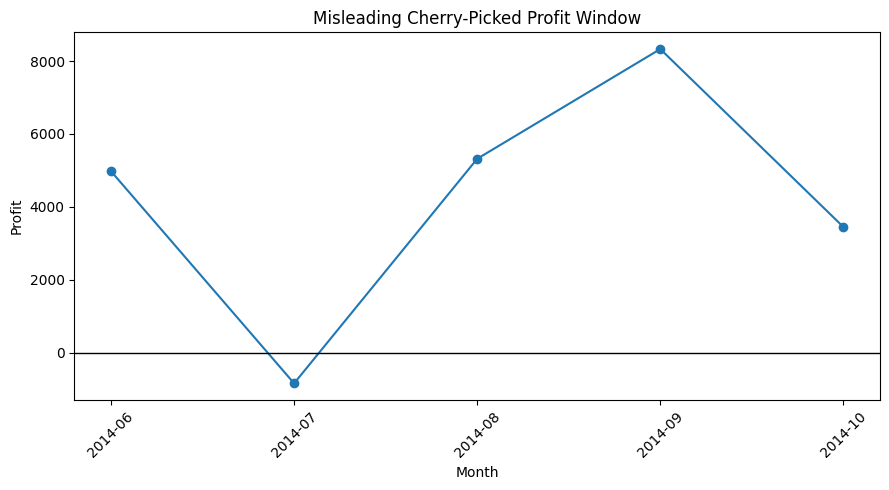

In [ ]:
short_window = monthly_profit.iloc[5:10]

plt.figure(figsize=(9, 5))
plt.plot(
    short_window.index,
    short_window.values,
    marker='o'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Misleading Cherry-Picked Profit Window')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5(d) Inverted y-axis

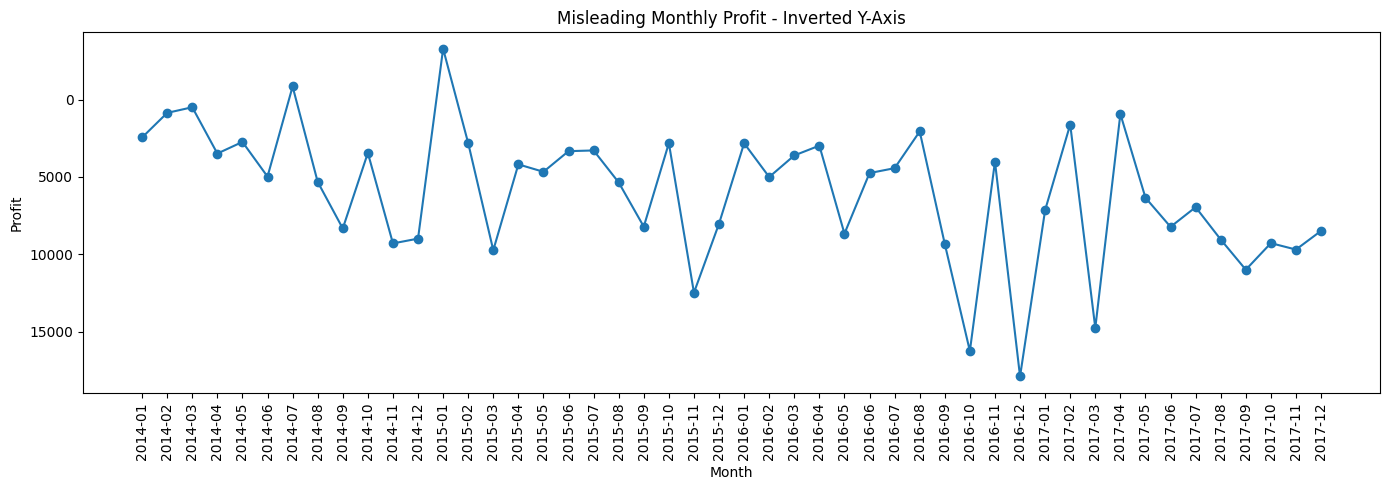

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker='o'
)

plt.gca().invert_yaxis()

plt.title('Misleading Monthly Profit - Inverted Y-Axis')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 5(e) Bubble chart with radius scaled by profit magnitude

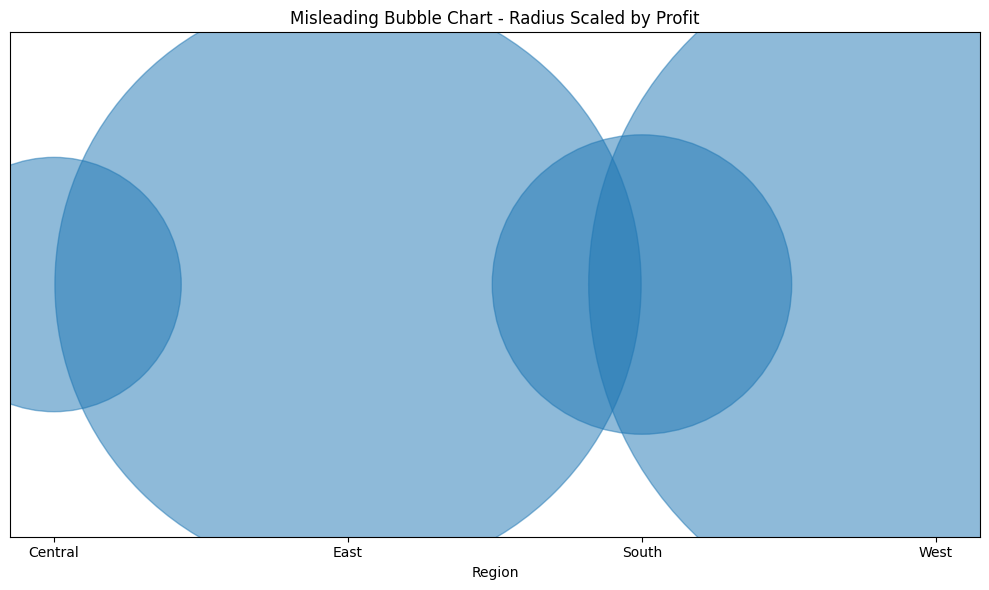

In [ ]:
bubble_values = region_profit.abs().values

radius = bubble_values / bubble_values.max() * 500

plt.figure(figsize=(10, 6))

plt.scatter(
    range(len(region_profit)),
    [1] * len(region_profit),
    s=radius ** 2,
    alpha=0.5
)

plt.xticks(
    range(len(region_profit)),
    region_profit.index
)

plt.yticks([])

plt.title('Misleading Bubble Chart - Radius Scaled by Profit')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

## Task 6

### 6(a) Honest chart

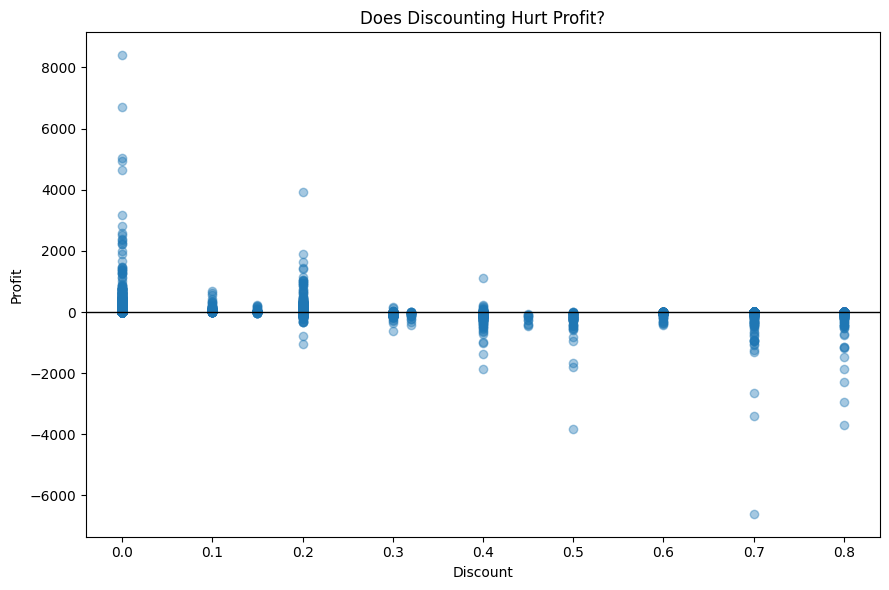

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Does Discounting Hurt Profit?')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### 6(b) Deliberately misleading chart

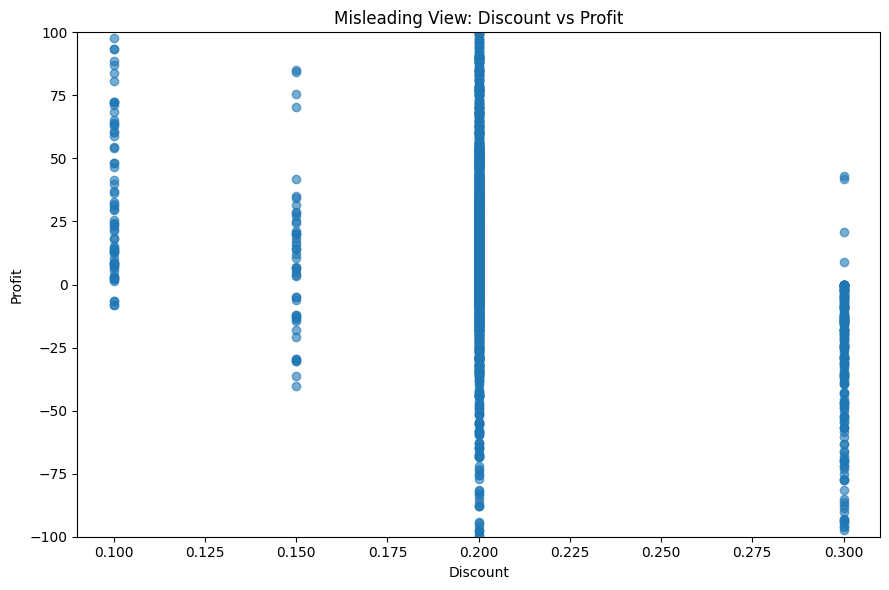

In [ ]:
filtered = df[
    (df['Discount'] >= 0.10)
    & (df['Discount'] <= 0.30)
]

plt.figure(figsize=(9, 6))

plt.scatter(
    filtered['Discount'],
    filtered['Profit'],
    alpha=0.6
)

plt.ylim(-100, 100)

plt.title('Misleading View: Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

Chart type: Scatter plot because Discount and Profit are continuous variables. \
Color choice: A single color is used so the interpretation does not depend on color. \
Accessibility check: The horizontal zero line provides a non-color indication of gain and loss.
> The honest chart uses all observations, while the misleading chart cherry-picks discount values and truncates the y-axis.